> **Experiment E02: Leakage audit**  
> Spec, decision rule and results: [docs/experiments/E02_leakage_audit.md](../docs/experiments/E02_leakage_audit.md)  
> Depends on: none · Status: done  
> Registered in `experiments/registry.yaml`; see the [experiment graph](../docs/experiments/EXPERIMENT_GRAPH.md).

In [1]:
# ==============================================================================
# OVERLAP VERIFICATION — CARE to Compare, Wind Farm C
# ==============================================================================
# SELF-CONTAINED. Does not depend on any earlier notebook's session state.
# Written so it can be published alongside the paper as verification code.
#
# CLAIM UNDER TEST
#   For specific pairs of sub-datasets from the same turbine, a contiguous block
#   of rows in one file contains the SAME sensor measurements as a contiguous
#   block in the other, after a whole-year time shift.
#
# TWO COMPETING HYPOTHESES
#   H1 (the dataset FAQ's account): files merely share timestamp RANGES as a
#       side effect of anonymization, while representing different real periods.
#       -> predicts sensor values at coinciding timestamps are UNRELATED.
#   H2 (ours): files share the same underlying DATA.
#       -> predicts sensor values are IDENTICAL after the correct shift.
#
# Eight tests. Tests 5 and 6 are negative controls and matter as much as the
# positive results — they establish the false-positive rate of the method.
#
# Runtime ~25-40 min on Kaggle CPU. No GPU needed.
# ==============================================================================



# ============================== CELL 1 ========================================
# SETUP
# ==============================================================================

import os, re, gc, json, hashlib, itertools, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)
rng = np.random.default_rng(0)

# ---- point this at the Wind Farm C datasets folder ---------------------------
FARM_DIR = Path("/kaggle/input/datasets/azizkasimov/"
                "wind-turbine-scada-data-for-early-fault-detection/"
                "Wind Farm C/datasets")
OUT = Path("/kaggle/working/overlap_verification")
OUT.mkdir(parents=True, exist_ok=True)

CFG = dict(
    fp_n=12,            # columns used to BUILD fingerprints
    holdout_n=20,       # disjoint columns used to VERIFY  (circularity fix)
    fp_dp=3,            # rounding for fingerprints
    min_match=30,       # minimum fingerprint matches to consider a pair
    tol=0.0,            # absolute tolerance for "identical". 0.0 = exact
    n_cross_turbine=30, # negative control pairs
    precision_sweep=[1, 2, 3, 4, 6],
)


def sniff_sep(p, n=3):
    with open(p, "r", errors="ignore") as fh:
        head = "".join(fh.readline() for _ in range(n))
    return ";" if head.count(";") > head.count(",") else ","


# resolve the file set (exclude comma_ duplicates if both encodings present)
allc = sorted(FARM_DIR.glob("*.csv"))
plain = [p for p in allc if not p.stem.lower().startswith("comma_")]
files = plain if plain else allc
files = sorted(files, key=lambda p: int(re.sub(r"\D", "", p.stem)))
SEP = sniff_sep(files[0])

print(f"files : {len(files)}   sep='{SEP}'   dir={FARM_DIR.name}")

header = pd.read_csv(files[0], sep=SEP, nrows=1)
AVG = [c for c in header.columns if c.endswith("_avg")]
print(f"_avg columns: {len(AVG)}")


files : 58   sep=';'   dir=datasets
_avg columns: 238


In [2]:
# ============================== CELL 2 ========================================
# CHOOSE COLUMNS — fingerprint set and a DISJOINT holdout set.
#
# Why this matters: if you verify using the same columns you matched on, a
# reviewer can call the test circular. The holdout set was never used to find
# the alignment, so agreement on it is independent confirmation.
# ==============================================================================

# cheap per-column stats from a sample of files
samp = pd.concat(
    [pd.read_csv(f, sep=SEP, usecols=AVG, nrows=8000).astype(np.float32)
     for f in files[:6]], ignore_index=True)

stats = pd.DataFrame({
    "col": AVG,
    "std": samp[AVG].std().values,
    "pct_zero": (samp[AVG] == 0).mean().values * 100,
    "n_unique": samp[AVG].nunique().values,
})
# good fingerprint material: varies continuously, rarely zero, many distinct values
good = stats[(stats.pct_zero < 5) & (stats.n_unique > 500)].sort_values(
    "std", ascending=False)

FP_COLS = good.head(CFG["fp_n"])["col"].tolist()
HOLDOUT = [c for c in good["col"].tolist() if c not in FP_COLS][:CFG["holdout_n"]]
ALL_TEST = [c for c in AVG if c not in FP_COLS]     # everything not used to match

print("FINGERPRINT columns (used to FIND alignment):")
for c in FP_COLS:
    print(f"   {c}")
print(f"\nHOLDOUT columns (used to VERIFY, disjoint): {len(HOLDOUT)}")
print(f"   {HOLDOUT[:6]} ...")
print(f"\nFULL-WIDTH test columns (all non-fingerprint): {len(ALL_TEST)}")

assert not set(FP_COLS) & set(HOLDOUT), "holdout must be disjoint"
del samp; gc.collect()


FINGERPRINT columns (used to FIND alignment):
   sensor_43_avg
   sensor_35_avg
   sensor_180_avg
   sensor_140_avg
   sensor_141_avg
   sensor_139_avg
   sensor_60_avg
   sensor_59_avg
   sensor_58_avg
   sensor_75_avg
   sensor_113_avg
   sensor_114_avg

HOLDOUT columns (used to VERIFY, disjoint): 20
   ['sensor_110_avg', 'sensor_109_avg', 'sensor_125_avg', 'sensor_112_avg', 'sensor_111_avg', 'sensor_116_avg'] ...

FULL-WIDTH test columns (all non-fingerprint): 226


10

In [3]:
# ============================== CELL 3 ========================================
# LOADERS
# ==============================================================================

def load(fn, cols):
    d = pd.read_csv(FARM_DIR / fn, sep=SEP,
                    usecols=["time_stamp", "asset_id", "status_type_id",
                             "train_test"] + cols)
    d["t"] = pd.to_datetime(d["time_stamp"])
    for c in cols:
        d[c] = pd.to_numeric(d[c], errors="coerce").astype(np.float64)
    return d


def fingerprint(d, cols, dp):
    """Unique fingerprints from production rows only (status 0)."""
    p = d[d.status_type_id == 0].copy()
    if not len(p):
        return pd.DataFrame(columns=["t", "fp", "idx"])
    v = p[cols].round(dp).astype(str).agg("|".join, axis=1)
    p["fp"] = [hashlib.blake2b(s.encode(), digest_size=12).hexdigest() for s in v]
    cnt = p["fp"].value_counts()
    p = p[p["fp"].isin(cnt[cnt == 1].index)]      # force one-to-one merges
    p["idx"] = p.index
    return p[["t", "fp", "idx"]].reset_index(drop=True)


# map every file to its turbine
asset_of = {}
for f in files:
    a = pd.read_csv(f, sep=SEP, usecols=["asset_id"], nrows=1)["asset_id"].iloc[0]
    asset_of[f.name] = int(a)

turbines = {}
for fn, a in asset_of.items():
    turbines.setdefault(a, []).append(fn)
turbines = {a: sorted(v, key=lambda x: int(x.split(".")[0]))
            for a, v in turbines.items()}

print(f"turbines: {len(turbines)}")
print(f"turbines with >1 sub-dataset: {sum(1 for v in turbines.values() if len(v) > 1)}")
print(f"within-turbine pairs to test: "
      f"{sum(len(v)*(len(v)-1)//2 for v in turbines.values())}")


turbines: 22
turbines with >1 sub-dataset: 19
within-turbine pairs to test: 64


In [4]:
# ============================== CELL 4 ========================================
# TESTS 1-4: run every within-turbine pair.
#
#   TEST 1  offset structure     — are matches a contiguous block or scatter?
#   TEST 2  holdout verification — do UNTOUCHED columns agree?
#   TEST 3  full-width           — do ALL non-fingerprint columns agree?
#   TEST 4  contiguity           — how many separate runs is the match?
# ==============================================================================

def contiguity(offsets_idx):
    """Given sorted matched row indices, count contiguous runs."""
    if len(offsets_idx) < 2:
        return len(offsets_idx), len(offsets_idx)
    s = np.sort(offsets_idx)
    breaks = np.where(np.diff(s) != 1)[0]
    runs = np.split(s, breaks + 1)
    return len(runs), max(len(r) for r in runs)


def compare_on(dA, dB, delta, cols, tol):
    """Align B onto A's clock by delta, compare raw values on `cols`."""
    B = dB.copy()
    B["t"] = B["t"] + delta
    j = dA.merge(B, on="t", suffixes=("_a", "_b"))
    if not len(j):
        return 0, np.nan, np.nan, 0
    per_col, ok_all = [], np.ones(len(j), bool)
    for c in cols:
        x, y = j[f"{c}_a"].values, j[f"{c}_b"].values
        both_nan = np.isnan(x) & np.isnan(y)
        eq = (np.isclose(x, y, rtol=0, atol=tol) | both_nan)
        per_col.append(eq.mean())
        ok_all &= eq
    return len(j), float(ok_all.mean()), float(np.min(per_col)), len(cols)


rows = []
for asset, fns in turbines.items():
    if len(fns) < 2:
        continue
    cache = {fn: load(fn, FP_COLS + HOLDOUT) for fn in fns}
    fps = {fn: fingerprint(cache[fn], FP_COLS, CFG["fp_dp"]) for fn in fns}

    for a, b in itertools.combinations(fns, 2):
        m = fps[a].merge(fps[b], on="fp", suffixes=("_a", "_b"))
        n_fp = len(m)
        if n_fp < CFG["min_match"]:
            rows.append(dict(asset_id=asset, file_a=a, file_b=b, n_fp=n_fp,
                             verdict="NO_MATCH"))
            continue

        # --- TEST 1: offset structure ------------------------------------------
        idx_off = (m.idx_a - m.idx_b).values
        t_delta = (m.t_a - m.t_b)
        modal = t_delta.mode().iloc[0]
        frac_mode = float((t_delta == modal).mean())

        # --- TEST 4: contiguity -------------------------------------------------
        n_runs, longest = contiguity(m.idx_a.values)

        # --- TEST 2: holdout verification --------------------------------------
        vr, vmatch, vmin, _ = compare_on(cache[a], cache[b], modal,
                                         HOLDOUT, CFG["tol"])

        rows.append(dict(
            asset_id=asset, file_a=a, file_b=b,
            n_fp=n_fp,
            delta=modal,
            offset_std=float(np.std(idx_off)),
            n_unique_offsets=int(len(np.unique(idx_off))),
            frac_at_modal_delta=frac_mode,
            n_runs=n_runs, longest_run=longest,
            verify_rows=vr,
            holdout_match=vmatch,
            holdout_worst_col=vmin,
            verdict="DUPLICATE" if (vmatch == 1.0 and vr > 0) else
                    "PARTIAL" if (vmatch is not np.nan and vmatch > 0.5) else
                    "NOT_DUPLICATE"))
        print(f"  {asset:>3} {a:>7} vs {b:<7} fp={n_fp:>6} "
              f"off_std={np.std(idx_off):9.2f} runs={n_runs:>4} "
              f"holdout={vmatch if vmatch==vmatch else float('nan'):.4f} ")

    del cache, fps
    gc.collect()

R = pd.DataFrame(rows)
R.to_csv(OUT / "pair_tests.csv", index=False)

print("\n" + "=" * 78)
print("TESTS 1-4 — WITHIN-TURBINE PAIRS")
print("=" * 78)
show = ["asset_id", "file_a", "file_b", "n_fp", "delta", "offset_std",
        "n_unique_offsets", "n_runs", "longest_run", "verify_rows",
        "holdout_match", "verdict"]
print(R[R.verdict != "NO_MATCH"][show].to_string(
    index=False, float_format=lambda x: f"{x:.4f}"))

print(f"\n  DUPLICATE     : {(R.verdict=='DUPLICATE').sum()}")
print(f"  PARTIAL       : {(R.verdict=='PARTIAL').sum()}")
print(f"  NOT_DUPLICATE : {(R.verdict=='NOT_DUPLICATE').sum()}")
print(f"  NO_MATCH      : {(R.verdict=='NO_MATCH').sum()}")


   53   1.csv vs 16.csv  fp= 36242 off_std=     0.00 runs= 482 holdout=1.0000 
   53   1.csv vs 20.csv  fp= 39304 off_std=     0.00 runs= 416 holdout=1.0000 
   53   1.csv vs 35.csv  fp= 45053 off_std=     0.00 runs= 603 holdout=1.0000 
   53   1.csv vs 60.csv  fp= 20889 off_std=     0.00 runs= 263 holdout=1.0000 
   53   1.csv vs 76.csv  fp= 34273 off_std=     0.00 runs= 462 holdout=1.0000 
   53  16.csv vs 20.csv  fp= 28287 off_std=     0.00 runs= 275 holdout=1.0000 
   53  16.csv vs 35.csv  fp= 34036 off_std=     0.00 runs= 462 holdout=1.0000 
   53  16.csv vs 60.csv  fp=  9872 off_std=     0.00 runs= 122 holdout=1.0000 
   53  16.csv vs 76.csv  fp= 43087 off_std=     0.00 runs= 580 holdout=1.0000 
   53  20.csv vs 35.csv  fp= 40536 off_std=     0.00 runs= 445 holdout=1.0000 
   53  20.csv vs 60.csv  fp= 31341 off_std=     0.00 runs= 408 holdout=1.0000 
   53  20.csv vs 76.csv  fp= 26318 off_std=     0.00 runs= 255 holdout=1.0000 
   53  35.csv vs 60.csv  fp= 22121 off_std=     0.00

In [6]:
# ============================== CELL 5 ========================================
# TEST 3 — FULL-WIDTH VERIFICATION on confirmed duplicates.
# Not 20 columns. ALL 226 non-fingerprint columns.
# ==============================================================================

dups = R[R.verdict == "DUPLICATE"]
full = []
for r in dups.itertuples():
    dA = load(r.file_a, ALL_TEST)
    dB = load(r.file_b, ALL_TEST)
    vr, vmatch, vmin, ncol = compare_on(dA, dB, r.delta, ALL_TEST, CFG["tol"])
    full.append(dict(asset_id=r.asset_id, file_a=r.file_a, file_b=r.file_b,
                     n_cols_tested=ncol, verify_rows=vr,
                     all_col_match=vmatch, worst_single_col=vmin))
    print(f"  {r.file_a:>7} vs {r.file_b:<7} {ncol} cols, {vr:>6} rows, "
          f"match={vmatch:.6f}, worst col={vmin:.6f}")
    del dA, dB; gc.collect()

F = pd.DataFrame(full)
F.to_csv(OUT / "full_width_verification.csv", index=False)

print("\n" + "=" * 78)
print("TEST 3 — FULL-WIDTH VERIFICATION")
print("=" * 78)
print(F.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
if len(F):
    print(f"\n  columns tested per pair : {F.n_cols_tested.iloc[0]}")
    print(f"  lowest all-column match : {F.all_col_match.min():.6f}")
    print(f"  lowest single-column    : {F.worst_single_col.min():.6f}")



    1.csv vs 16.csv  226 cols,  41617 rows, match=1.000000, worst col=1.000000
    1.csv vs 20.csv  226 cols,  42344 rows, match=1.000000, worst col=1.000000
    1.csv vs 35.csv  226 cols,  51319 rows, match=1.000000, worst col=1.000000
    1.csv vs 60.csv  226 cols,  22066 rows, match=1.000000, worst col=1.000000
    1.csv vs 76.csv  226 cols,  39601 rows, match=1.000000, worst col=1.000000
   16.csv vs 20.csv  226 cols,  30392 rows, match=1.000000, worst col=1.000000
   16.csv vs 35.csv  226 cols,  39367 rows, match=1.000000, worst col=1.000000
   16.csv vs 60.csv  226 cols,  10114 rows, match=1.000000, worst col=1.000000
   16.csv vs 76.csv  226 cols,  51552 rows, match=1.000000, worst col=1.000000
   20.csv vs 35.csv  226 cols,  43640 rows, match=1.000000, worst col=1.000000
   20.csv vs 60.csv  226 cols,  33723 rows, match=1.000000, worst col=1.000000
   20.csv vs 76.csv  226 cols,  28376 rows, match=1.000000, worst col=1.000000
   35.csv vs 60.csv  226 cols,  23362 rows, match=1.

In [7]:
# ============================== CELL 7 ========================================
# TEST 6 — NEGATIVE CONTROL B: WRONG-DELTA.
#
# Take a confirmed duplicate pair and apply deliberately WRONG shifts.
# If the match survives a wrong shift, the match means nothing.
# ==============================================================================

wrong = []
if len(dups):
    r = dups.iloc[0]
    dA = load(r.file_a, HOLDOUT); dB = load(r.file_b, HOLDOUT)
    offsets = [pd.Timedelta(0), pd.Timedelta(minutes=10), pd.Timedelta(hours=1),
               pd.Timedelta(days=1), pd.Timedelta(days=7), pd.Timedelta(days=30)]
    for off in offsets:
        vr, vm, _, _ = compare_on(dA, dB, r.delta + off, HOLDOUT, CFG["tol"])
        wrong.append(dict(applied_offset=str(off), rows=vr,
                          match=vm, correct=(off == pd.Timedelta(0))))
    del dA, dB; gc.collect()

W = pd.DataFrame(wrong)
W.to_csv(OUT / "control_wrong_delta.csv", index=False)

print("=" * 78)
print("TEST 6 — NEGATIVE CONTROL: WRONG DELTA")
print(f"pair: {dups.iloc[0].file_a} vs {dups.iloc[0].file_b}"
      if len(dups) else "no duplicates found")
print("=" * 78)
print(W.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
print("\n  EXPECTED: match = 1.0 at offset 0, collapsing toward 0 elsewhere.")
print("  A flat profile would mean the columns are constant and prove nothing.")


TEST 6 — NEGATIVE CONTROL: WRONG DELTA
pair: 1.csv vs 16.csv
  applied_offset  rows    match  correct
 0 days 00:00:00 41617 1.000000     True
 0 days 00:10:00 41614 0.007834    False
 0 days 01:00:00 41599 0.007140    False
 1 days 00:00:00 41185 0.000024    False
 7 days 00:00:00 39889 0.001529    False
30 days 00:00:00 36145 0.000000    False

  EXPECTED: match = 1.0 at offset 0, collapsing toward 0 elsewhere.
  A flat profile would mean the columns are constant and prove nothing.


In [8]:
# ============================== CELL 8 ========================================
# TEST 7 — H1 vs H2 DISCRIMINATION.
#
# The dataset FAQ says files may share TIMESTAMP RANGES while representing
# different periods. That predicts values at SHARED RAW timestamps (no shift)
# are unrelated. Test it directly on every pair.
# ==============================================================================

h = []
for asset, fns in turbines.items():
    if len(fns) < 2:
        continue
    cache = {fn: load(fn, HOLDOUT) for fn in fns}
    for a, b in itertools.combinations(fns, 2):
        # raw overlap: NO shift applied
        vr0, vm0, _, _ = compare_on(cache[a], cache[b],
                                    pd.Timedelta(0), HOLDOUT, CFG["tol"])
        rr = R[(R.file_a == a) & (R.file_b == b)]
        vm_shift = rr.holdout_match.iloc[0] if len(rr) else np.nan
        dl = rr.delta.iloc[0] if len(rr) else pd.NaT
        h.append(dict(asset_id=asset, file_a=a, file_b=b,
                      shared_raw_timestamps=vr0,
                      match_at_raw_timestamps=vm0,
                      fitted_delta=dl,
                      match_after_shift=vm_shift))
    del cache; gc.collect()

H = pd.DataFrame(h)
H.to_csv(OUT / "h1_vs_h2.csv", index=False)

print("=" * 78)
print("TEST 7 — H1 (shared ranges) vs H2 (shared data)")
print("=" * 78)
print(H.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

zero_shift = H[H.fitted_delta == pd.Timedelta(0)]
nonzero = H[(H.fitted_delta.notna()) & (H.fitted_delta != pd.Timedelta(0))]
h1_cases = H[(H.shared_raw_timestamps > 0) & (H.match_at_raw_timestamps < 0.5)]

print(f"\n  pairs sharing raw timestamps but NOT matching in value : {len(h1_cases)}")
print("     -> these ARE the phenomenon the FAQ describes (H1). Report them.")
print(f"  pairs matching only after a non-zero shift             : {len(nonzero)}")
print("     -> H1 cannot explain these. Values identical at a shifted time.")
print(f"  pairs matching at zero shift                           : {len(zero_shift)}")
print("     -> same dates AND same values: duplication, not coincidence.")


TEST 7 — H1 (shared ranges) vs H2 (shared data)
 asset_id file_a file_b  shared_raw_timestamps  match_at_raw_timestamps fitted_delta  match_after_shift
       53  1.csv 16.csv                  41617                   1.0000       0 days             1.0000
       53  1.csv 20.csv                  42344                   1.0000       0 days             1.0000
       53  1.csv 35.csv                  51319                   1.0000       0 days             1.0000
       53  1.csv 60.csv                  22066                   1.0000       0 days             1.0000
       53  1.csv 76.csv                  14646                   0.0000     365 days             1.0000
       53 16.csv 20.csv                  30392                   1.0000       0 days             1.0000
       53 16.csv 35.csv                  39367                   1.0000       0 days             1.0000
       53 16.csv 60.csv                  10114                   1.0000       0 days             1.0000
       53 16.csv

In [9]:

# ============================== CELL 6 ========================================
# TEST 5 — NEGATIVE CONTROL A: CROSS-TURBINE PAIRS.
#
# Different turbines cannot share data. If the method reports overlap here,
# the method is broken. This establishes the false-positive rate.
# ==============================================================================

multi = [a for a, v in turbines.items() if len(v) >= 1]
pairs_x = []
while len(pairs_x) < CFG["n_cross_turbine"]:
    a1, a2 = rng.choice(multi, 2, replace=False)
    if a1 == a2:
        continue
    f1 = rng.choice(turbines[a1]); f2 = rng.choice(turbines[a2])
    if (f1, f2) not in pairs_x:
        pairs_x.append((f1, f2))

xrows = []
for f1, f2 in pairs_x:
    d1 = load(f1, FP_COLS + HOLDOUT); d2 = load(f2, FP_COLS + HOLDOUT)
    p1 = fingerprint(d1, FP_COLS, CFG["fp_dp"])
    p2 = fingerprint(d2, FP_COLS, CFG["fp_dp"])
    m = p1.merge(p2, on="fp", suffixes=("_a", "_b"))
    if len(m) >= CFG["min_match"]:
        modal = (m.t_a - m.t_b).mode().iloc[0]
        vr, vm, _, _ = compare_on(d1, d2, modal, HOLDOUT, CFG["tol"])
    else:
        vm, vr = np.nan, 0
    xrows.append(dict(file_a=f1, file_b=f2,
                      asset_a=asset_of[f1], asset_b=asset_of[f2],
                      n_fp=len(m), verify_rows=vr, holdout_match=vm))
    del d1, d2; gc.collect()

X = pd.DataFrame(xrows)
X.to_csv(OUT / "control_cross_turbine.csv", index=False)

print("=" * 78)
print("TEST 5 — NEGATIVE CONTROL: CROSS-TURBINE")
print("=" * 78)
print(X.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print(f"\n  pairs tested                    : {len(X)}")
print(f"  pairs exceeding match threshold : {(X.n_fp >= CFG['min_match']).sum()}")
print(f"  pairs verifying as duplicate    : {(X.holdout_match == 1.0).sum()}")
print("\n  EXPECTED: zero duplicates. Any non-zero means the method")
print("  produces false positives and the main result needs re-examination.")





TEST 5 — NEGATIVE CONTROL: CROSS-TURBINE
file_a file_b  asset_a  asset_b  n_fp  verify_rows  holdout_match
47.csv 37.csv       21       23     0            0            NaN
 4.csv 60.csv       34       53     0            0            NaN
91.csv 85.csv       42       14     0            0            NaN
85.csv 75.csv       14       44     0            0            NaN
85.csv 79.csv       14       16     0            0            NaN
76.csv 70.csv       53       23     0            0            NaN
76.csv 44.csv       53       44     0            0            NaN
90.csv  4.csv       56       34     0            0            NaN
29.csv 33.csv       13       43     0            0            NaN
89.csv  1.csv        5       53     0            0            NaN
37.csv 65.csv       23       16     0            0            NaN
66.csv 75.csv       12       44     0            0            NaN
85.csv 66.csv       14       12     0            0            NaN
91.csv 63.csv       42       56    

In [10]:
# ============================== CELL 9 ========================================
# TEST 8 — PRECISION SWEEP.
# True duplicates match at full precision. Coincidental matches evaporate
# as you demand more decimal places.
# ==============================================================================

sweep = []
sample_pairs = (dups.head(5) if len(dups) else pd.DataFrame()).itertuples()
for r in sample_pairs:
    dA = load(r.file_a, FP_COLS + HOLDOUT); dB = load(r.file_b, FP_COLS + HOLDOUT)
    for dp in CFG["precision_sweep"]:
        pa = fingerprint(dA, FP_COLS, dp); pb = fingerprint(dB, FP_COLS, dp)
        m = pa.merge(pb, on="fp")
        sweep.append(dict(pair=f"{r.file_a}|{r.file_b}", decimals=dp,
                          n_matches=len(m)))
    del dA, dB; gc.collect()

S = pd.DataFrame(sweep)
S.to_csv(OUT / "precision_sweep.csv", index=False)

print("=" * 78)
print("TEST 8 — PRECISION SWEEP")
print("=" * 78)
if len(S):
    print(S.pivot(index="pair", columns="decimals",
                  values="n_matches").to_string())
print("\n  EXPECTED for true duplicates: match count roughly FLAT across")
print("  decimal places. A sharp fall as precision rises indicates collisions.")



TEST 8 — PRECISION SWEEP
decimals          1      2      3      4      6
pair                                           
1.csv|16.csv  36242  36242  36242  36242  36242
1.csv|20.csv  39304  39304  39304  39304  39304
1.csv|35.csv  45053  45053  45053  45053  45053
1.csv|60.csv  20889  20889  20889  20889  20889
1.csv|76.csv  34273  34273  34273  34273  34273

  EXPECTED for true duplicates: match count roughly FLAT across
  decimal places. A sharp fall as precision rises indicates collisions.


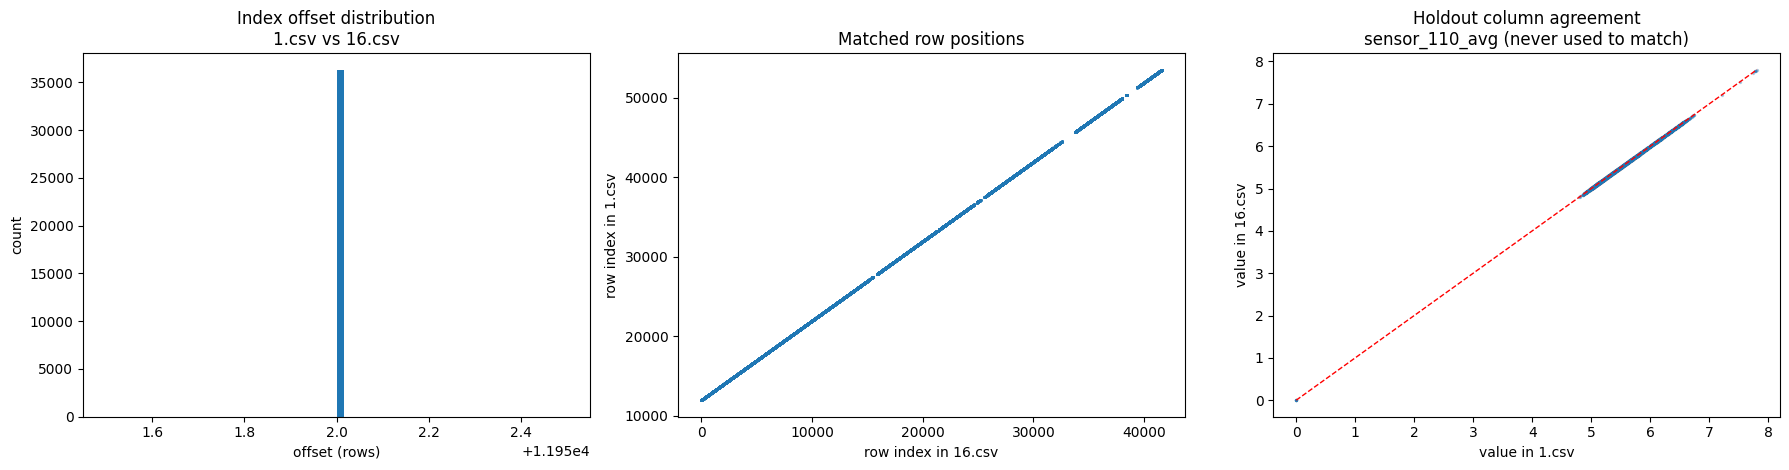

In [11]:
# ============================== CELL 10 =======================================
# FIGURES
# ==============================================================================

if len(dups):
    r = dups.iloc[0]
    dA = load(r.file_a, FP_COLS + HOLDOUT); dB = load(r.file_b, FP_COLS + HOLDOUT)
    pa = fingerprint(dA, FP_COLS, CFG["fp_dp"]); pb = fingerprint(dB, FP_COLS, CFG["fp_dp"])
    m = pa.merge(pb, on="fp", suffixes=("_a", "_b"))

    fig, ax = plt.subplots(1, 3, figsize=(18, 4.8))

    ax[0].hist(m.idx_a - m.idx_b, bins=60)
    ax[0].set(title=f"Index offset distribution\n{r.file_a} vs {r.file_b}",
              xlabel="offset (rows)", ylabel="count")

    ax[1].scatter(m.idx_b, m.idx_a, s=1, alpha=0.4)
    ax[1].set(title="Matched row positions", xlabel=f"row index in {r.file_b}",
              ylabel=f"row index in {r.file_a}")

    c = HOLDOUT[0]
    B2 = dB.copy(); B2["t"] = B2["t"] + r.delta
    j = dA.merge(B2, on="t", suffixes=("_a", "_b")).head(4000)
    ax[2].scatter(j[f"{c}_a"], j[f"{c}_b"], s=2, alpha=0.3)
    lo = float(min(j[f"{c}_a"].min(), j[f"{c}_b"].min()))
    hi = float(max(j[f"{c}_a"].max(), j[f"{c}_b"].max()))
    ax[2].plot([lo, hi], [lo, hi], "r--", lw=1)
    ax[2].set(title=f"Holdout column agreement\n{c} (never used to match)",
              xlabel=f"value in {r.file_a}", ylabel=f"value in {r.file_b}")

    plt.tight_layout()
    plt.savefig(OUT / "overlap_evidence.png", dpi=140)
    plt.show()
    del dA, dB; gc.collect()



In [12]:

# ============================== CELL 11 =======================================
# EVIDENCE SUMMARY
# ==============================================================================

print("=" * 78)
print("EVIDENCE SUMMARY")
print("=" * 78)

tested = R[R.verdict != "NO_MATCH"]
lines = [
    ("Within-turbine pairs tested", len(R)),
    ("Pairs with sufficient fingerprint matches", len(tested)),
    ("Pairs verified as DUPLICATE", int((R.verdict == 'DUPLICATE').sum())),
    ("Pairs NOT duplicates", int((R.verdict == 'NOT_DUPLICATE').sum())),
    ("", ""),
    ("TEST 1  max offset std among duplicates",
     f"{tested[tested.verdict=='DUPLICATE'].offset_std.max():.4f}"
     if (R.verdict == 'DUPLICATE').any() else "n/a"),
    ("TEST 2  worst holdout match among duplicates",
     f"{tested[tested.verdict=='DUPLICATE'].holdout_match.min():.6f}"
     if (R.verdict == 'DUPLICATE').any() else "n/a"),
    ("TEST 3  worst full-width match",
     f"{F.all_col_match.min():.6f}" if len(F) else "n/a"),
    ("TEST 3  columns tested per pair",
     int(F.n_cols_tested.iloc[0]) if len(F) else "n/a"),
    ("TEST 4  max contiguous runs among duplicates",
     int(tested[tested.verdict == 'DUPLICATE'].n_runs.max())
     if (R.verdict == 'DUPLICATE').any() else "n/a"),
    ("", ""),
    ("TEST 5  cross-turbine false positives",
     int((X.holdout_match == 1.0).sum())),
    ("TEST 6  match at wrong delta (max)",
     f"{W[~W.correct].match.max():.6f}" if len(W) else "n/a"),
    ("TEST 7  pairs explicable by H1 only", len(h1_cases)),
    ("TEST 7  pairs requiring H2", int((R.verdict == 'DUPLICATE').sum())),
    ("", ""),
    ("Distinct time shifts observed",
     sorted(set(str(d) for d in R.delta.dropna()))),
]
for k, v in lines:
    print(f"  {k:<46} {v}" if k else "")

json.dump({k: str(v) for k, v in lines if k},
          open(OUT / "evidence_summary.json", "w"), indent=2)

print("\n" + "=" * 78)
print("SAVED")
print("=" * 78)
for p in sorted(OUT.iterdir()):
    print(f"  {p.name:<34} {p.stat().st_size/1024:8.1f} KB")

EVIDENCE SUMMARY
  Within-turbine pairs tested                    64
  Pairs with sufficient fingerprint matches      49
  Pairs verified as DUPLICATE                    49
  Pairs NOT duplicates                           0

  TEST 1  max offset std among duplicates        0.0000
  TEST 2  worst holdout match among duplicates   1.000000
  TEST 3  worst full-width match                 1.000000
  TEST 3  columns tested per pair                226
  TEST 4  max contiguous runs among duplicates   603

  TEST 5  cross-turbine false positives          0
  TEST 6  match at wrong delta (max)             0.007834
  TEST 7  pairs explicable by H1 only            24
  TEST 7  pairs requiring H2                     49

  Distinct time shifts observed                  ['-365 days +00:00:00', '0 days 00:00:00', '365 days 00:00:00']

SAVED
  control_cross_turbine.csv               0.8 KB
  control_wrong_delta.csv                 0.3 KB
  evidence_summary.json                   0.7 KB
  full_width_ve

Turbine 53: 6 sub-datasets -> ['1.csv', '16.csv', '20.csv', '35.csv', '60.csv', '76.csv']
  1.csv      53,569 rows    47,259 unique fingerprints   raw span 2022-10-01 to 2023-10-16
  16.csv     53,568 rows    45,215 unique fingerprints   raw span 2022-12-23 to 2024-01-07
  20.csv     54,001 rows    49,756 unique fingerprints   raw span 2022-07-12 to 2023-07-30
  35.csv     52,615 rows    47,171 unique fingerprints   raw span 2022-09-22 to 2023-09-30
  60.csv     54,433 rows    43,645 unique fingerprints   raw span 2022-02-14 to 2023-03-03
  76.csv     52,086 rows    43,469 unique fingerprints   raw span 2022-01-06 to 2023-01-11

All joins below are on fingerprint identity. No shift is ever fitted.


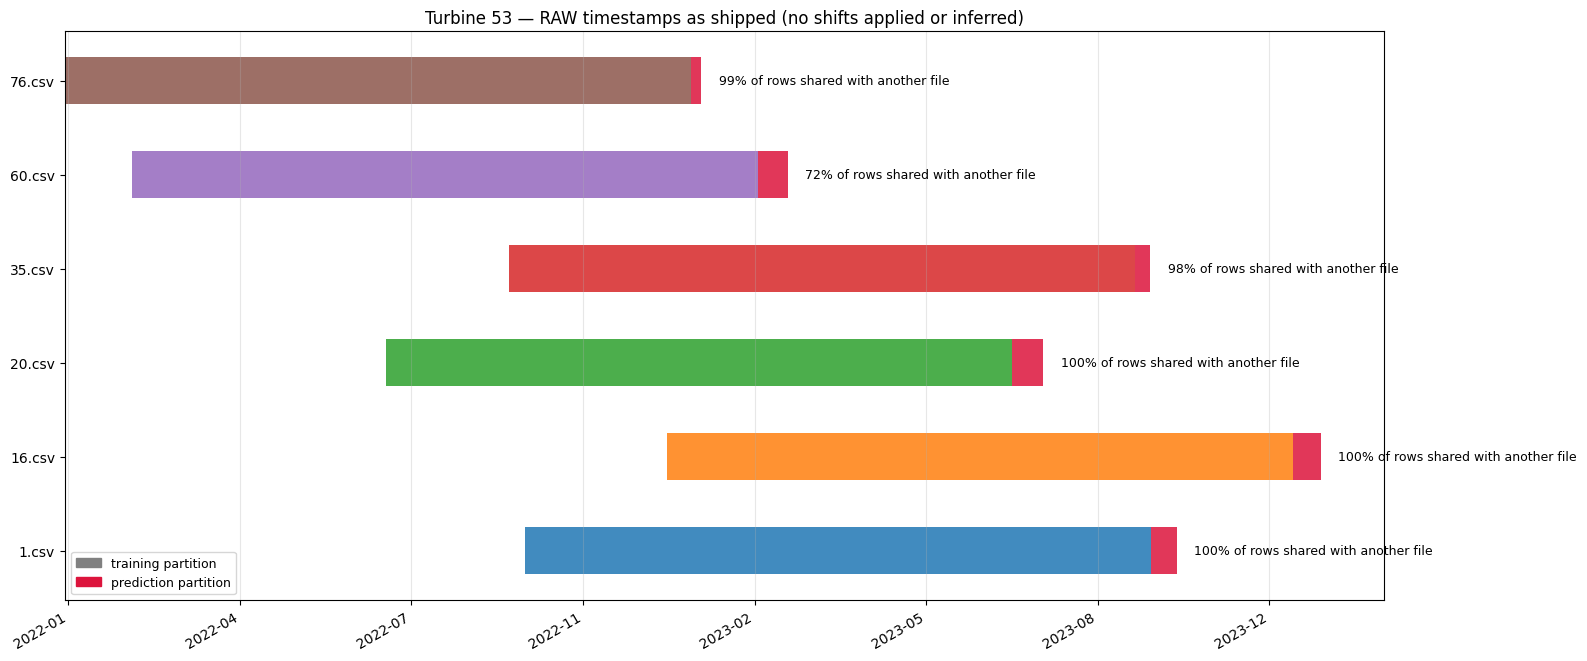

READ IT: the visual overlap of the bars proves nothing — it is an
artefact of every file being shifted to 2022. The percentages on the
right come from fingerprints and are the actual measurement.


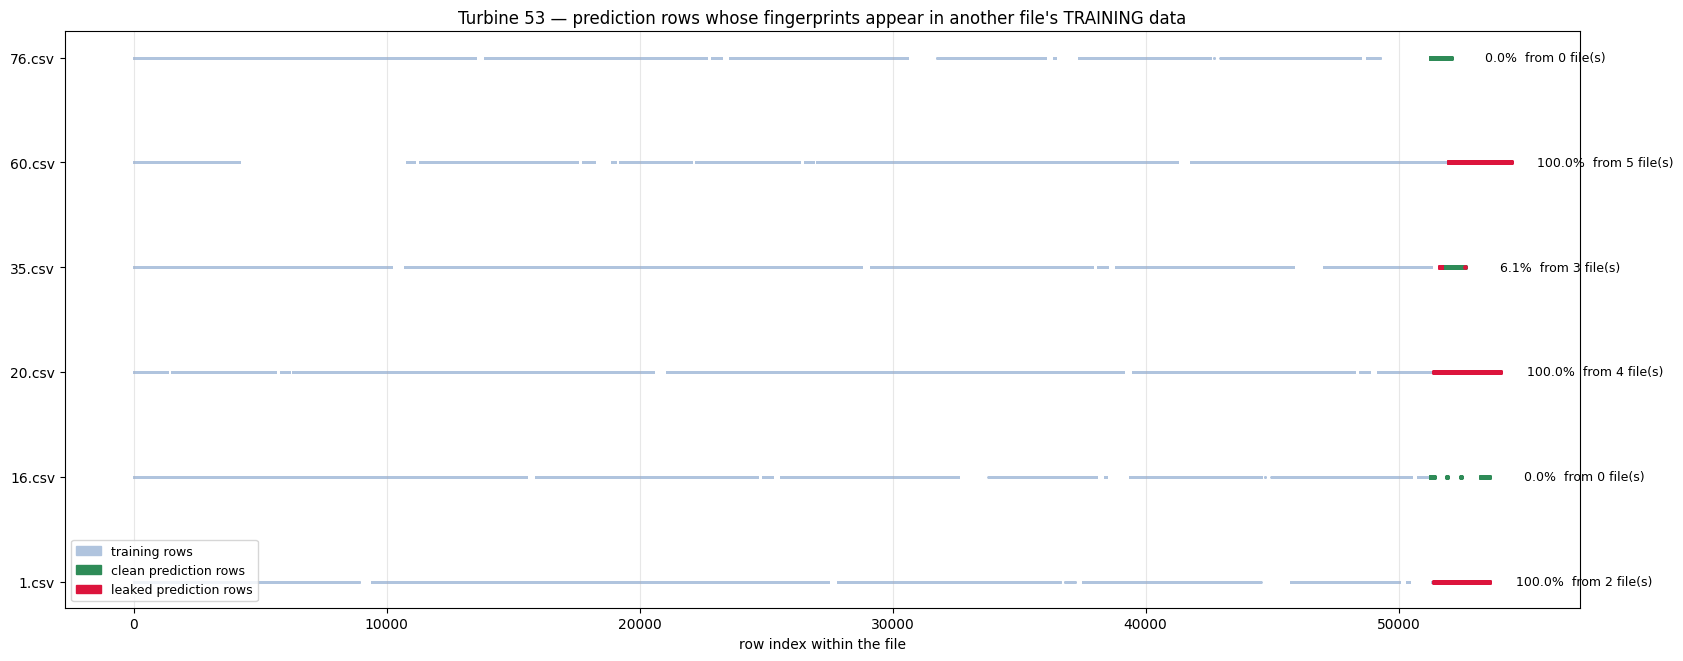

  file  pred_fps  contaminated   pct                     contaminators
 1.csv      2121          2121 100.0                     16.csv,76.csv
16.csv       445             0   0.0                                  
20.csv      2492          2492 100.0        1.csv,16.csv,35.csv,76.csv
35.csv       944            58   6.1               1.csv,16.csv,76.csv
60.csv      2376          2376 100.0 1.csv,16.csv,20.csv,35.csv,76.csv
76.csv       668             0   0.0                                  

READ IT: red means this exact measurement is in another file's training
data. Under federated learning the global model has already seen it.
time-free fingerprint universe: 80,256 unique fingerprints


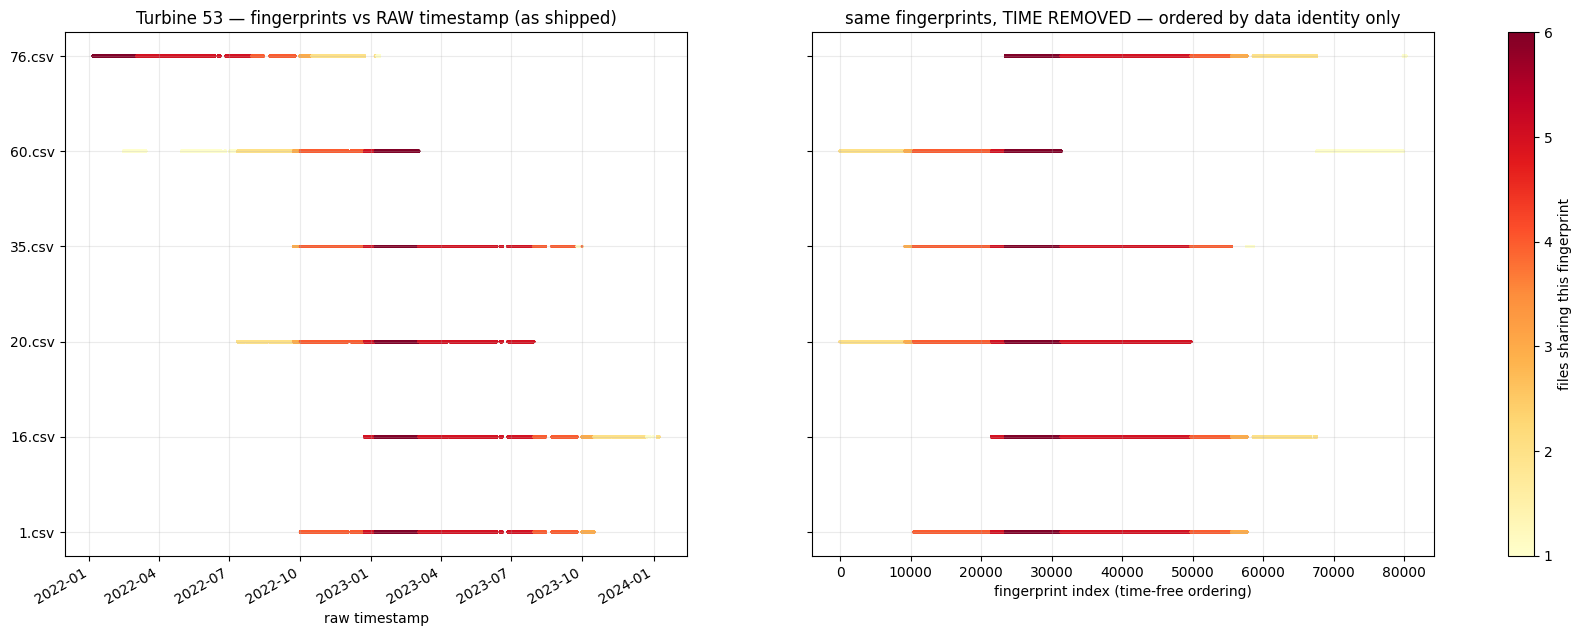

READ IT: the right panel contains no time information at all. The block
structure survives, so the sharing is a property of the MEASUREMENTS,
not of the dates attached to them.


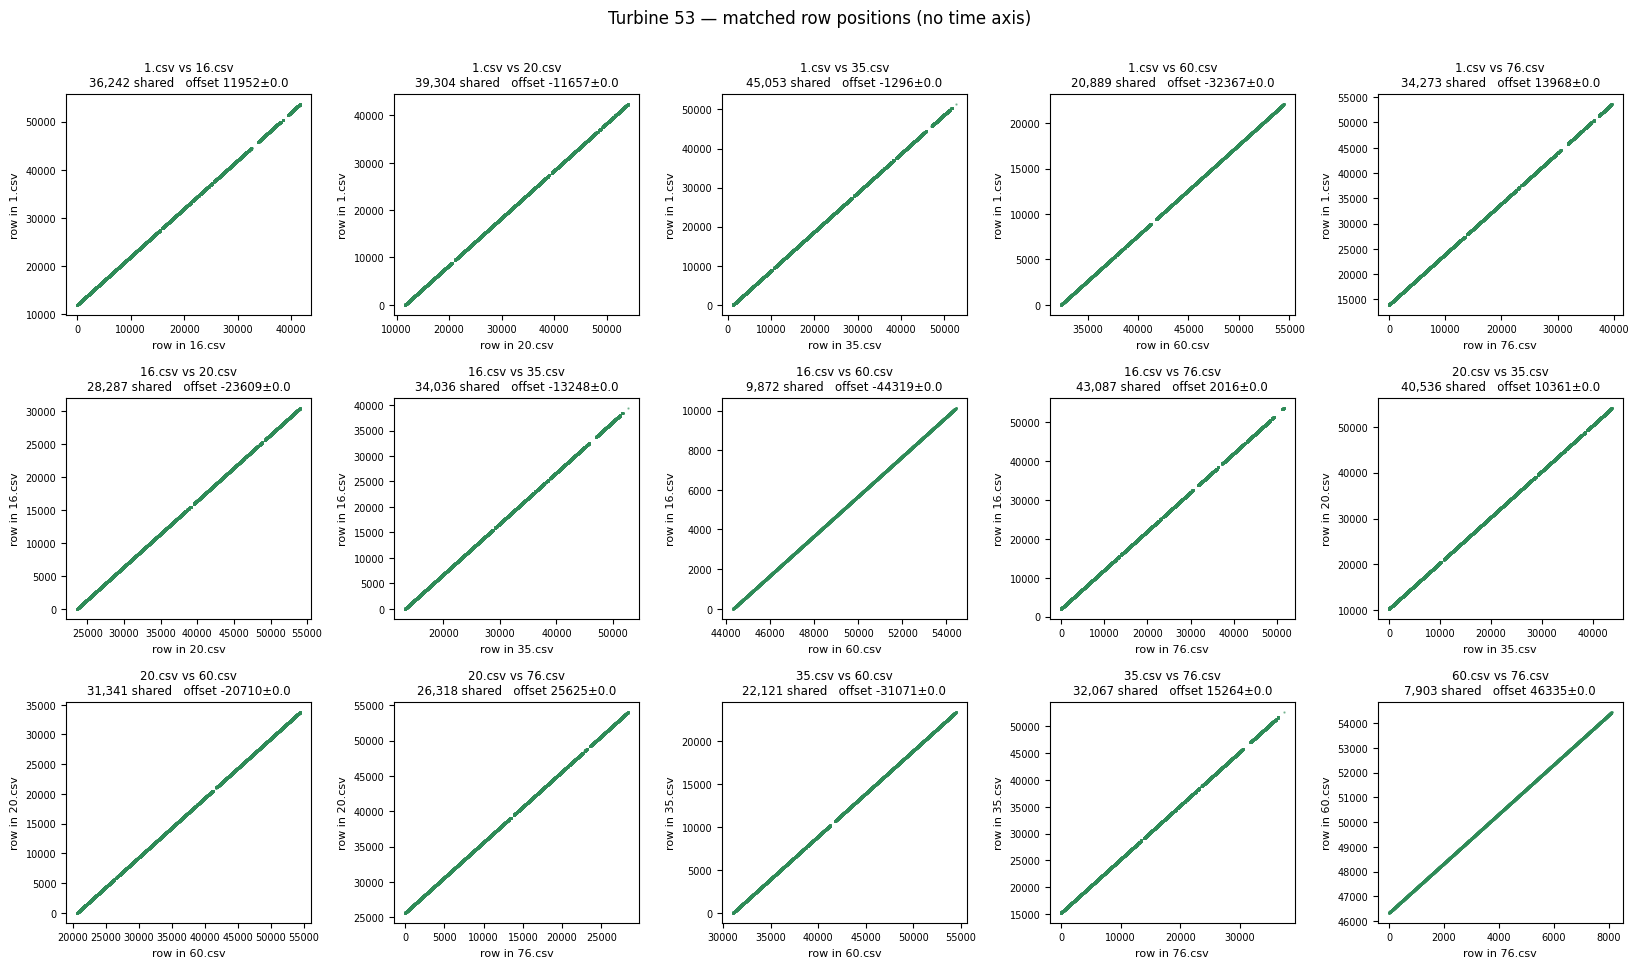

READ IT: offset ± 0.0 means every matched row sits the same distance
apart — one contiguous block. A scatter would mean coincidence.


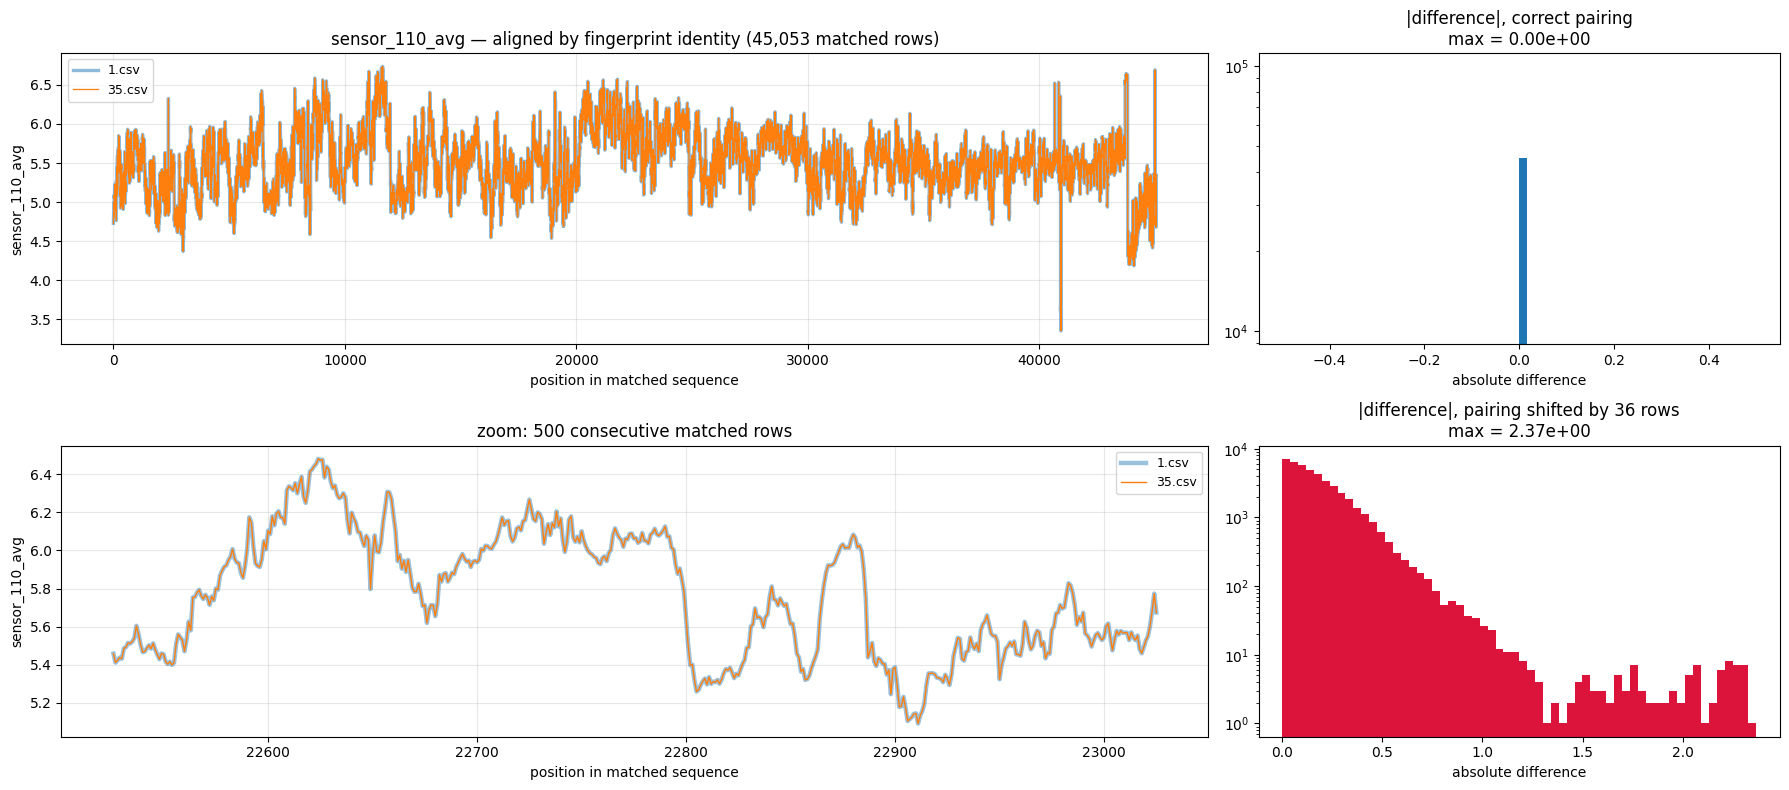

max |difference|, correct pairing : 0.000e+00   (expect 0.0)
max |difference|, shifted by 36    : 2.368e+00   (expect large)

READ IT: two lines that render as one. The bottom-right panel shows
what a wrong pairing looks like — the contrast is the point.


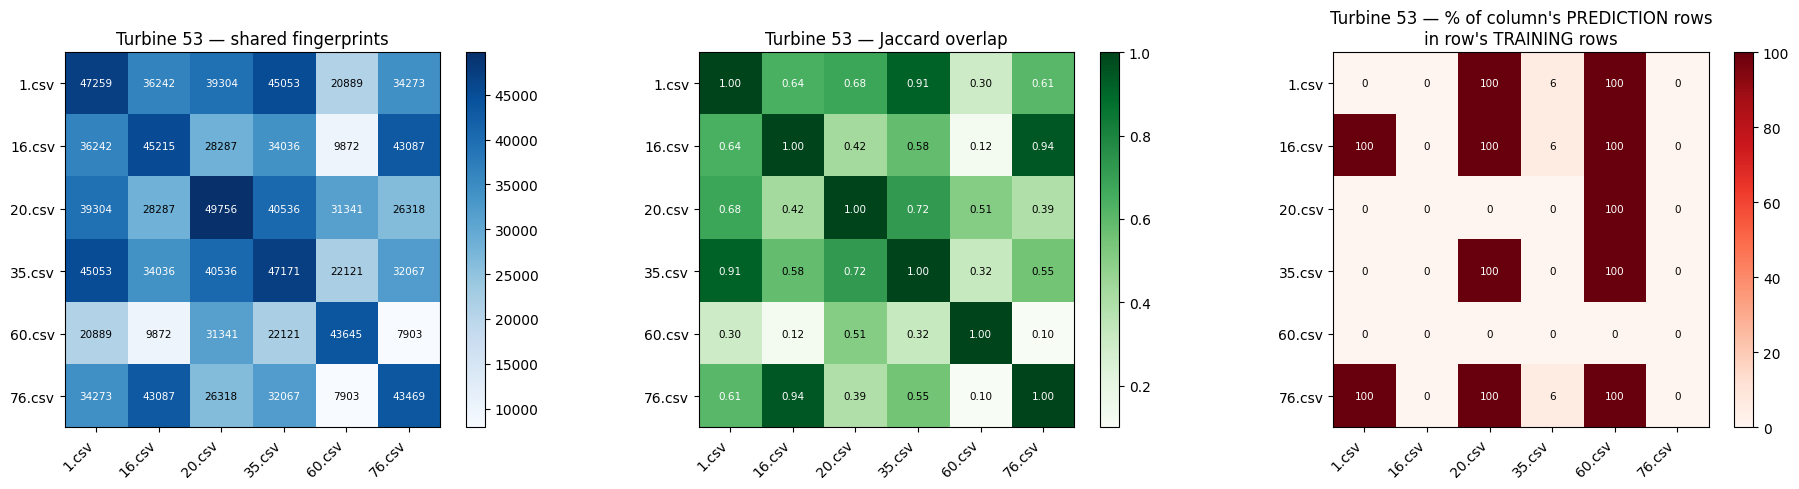

READ IT: the third panel is DIRECTED and is the one that matters for
federated learning. Row i, column j = how much of file j's evaluation
data sits in file i's training data. 100 means total contamination.


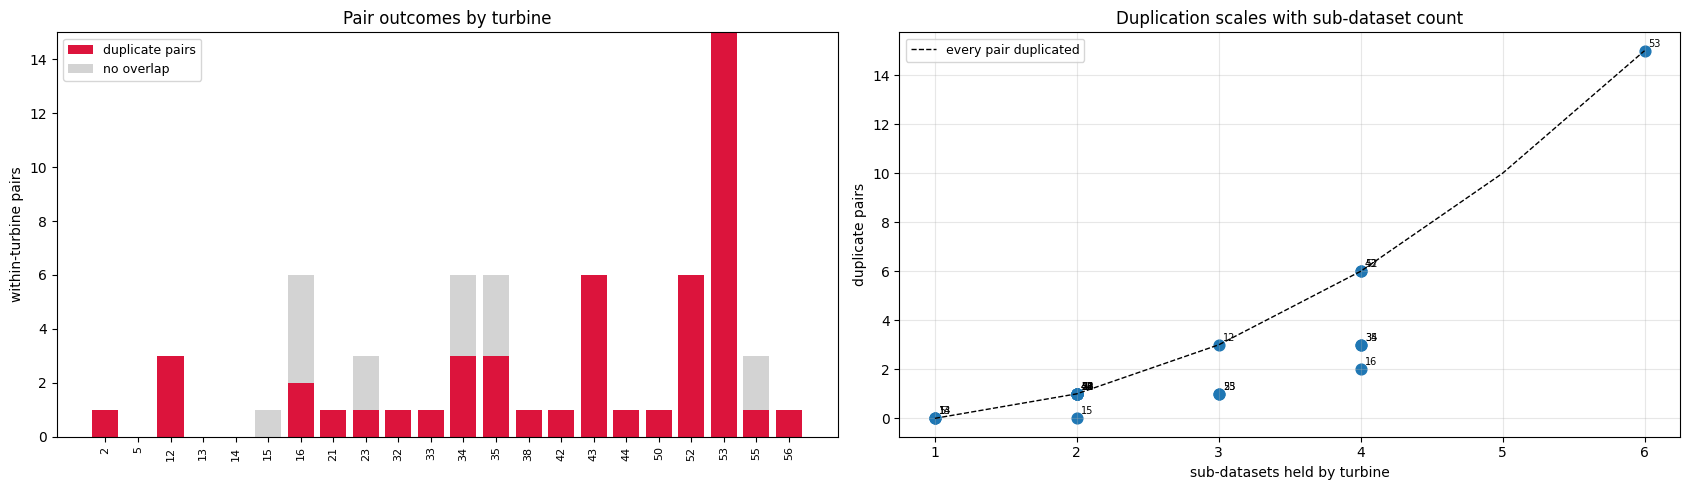

READ IT: points on the dashed line have EVERY pair duplicated.

saved to /kaggle/working/overlap_verification/figures


In [15]:
# ==============================================================================
# OVERLAP VISUALISATION — NO TIME-SHIFT RECONSTRUCTION
# ==============================================================================
# Every figure here uses either RAW timestamps exactly as shipped, or no time
# at all. Files are joined on FINGERPRINT IDENTITY, never on a fitted offset.
#
# Why this is the stronger position: a reconstructed shift is a derived
# quantity, and a sceptical reader can ask how it was fitted. A fingerprint
# match is a direct observation — these rows carry the same measurements.
# Nothing below depends on knowing, or guessing, how the timestamps were moved.
#
# Run after the verification notebook, same session.
# Needs: FARM_DIR, SEP, turbines, FP_COLS, HOLDOUT, load(), fingerprint(),
#        CFG, OUT
# ==============================================================================


# ============================== CELL V1 =======================================
# CONFIG AND LOADING — no shifts computed anywhere
# ==============================================================================

import numpy as np, pandas as pd, itertools, gc
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch

TURBINE = 53                      # <- change to inspect other turbines
FIGDIR = OUT / "figures"; FIGDIR.mkdir(exist_ok=True)

fns = turbines[TURBINE]
print(f"Turbine {TURBINE}: {len(fns)} sub-datasets -> {fns}")

PLOT_COLS = FP_COLS + HOLDOUT[:3]     # was: FP_COLS[:2] + HOLDOUT[:3]
D, FP = {}, {}
for f in fns:
    d = load(f, PLOT_COLS)
    d["is_train"] = d.train_test.astype(str).str.lower().str.startswith("train")
    D[f] = d
    FP[f] = fingerprint(d, FP_COLS, CFG["fp_dp"])
    # tag each fingerprint with the partition it came from — needed for leakage
    FP[f] = FP[f].merge(d[["is_train"]], left_on="idx", right_index=True, how="left")
    print(f"  {f:<9} {len(d):>7,} rows   {len(FP[f]):>7,} unique fingerprints"
          f"   raw span {d.t.min().date()} to {d.t.max().date()}")

COL = plt.cm.tab10(np.linspace(0, 1, 10))

# ---- the only join used in this notebook -------------------------------------
def shared(a, b):
    """Rows of a and b carrying identical fingerprints. No time involved."""
    return FP[a].merge(FP[b], on="fp", suffixes=("_a", "_b"))

print("\nAll joins below are on fingerprint identity. No shift is ever fitted.")


# ============================== CELL V2 =======================================
# FIGURE 1 — RAW TIMELINE, AND WHY IT MISLEADS
#
# Files are drawn on the timestamps exactly as shipped. Bars pile up because
# every file was moved to start in 2022. The overlap you SEE here is the
# labelling artefact the dataset FAQ describes — it is not evidence of anything.
# The annotation shows what the fingerprints say instead.
# ==============================================================================

fig, ax = plt.subplots(figsize=(16, 0.62 * len(fns) + 3))

for i, f in enumerate(fns):
    d = D[f]
    for mask, colr, h in [(d.is_train, COL[i % 10], 0.5),
                          (~d.is_train, "crimson", 0.5)]:
        s = d[mask]
        if len(s):
            ax.barh(i, mdates.date2num(s.t.max()) - mdates.date2num(s.t.min()),
                    left=mdates.date2num(s.t.min()), height=h,
                    color=colr, alpha=0.85)
    # how much of this file's data is fingerprint-shared with any other file
    mine = set(FP[f].fp)
    others = set().union(*[set(FP[g].fp) for g in fns if g != f]) if len(fns) > 1 else set()
    pct = 100 * len(mine & others) / max(len(mine), 1)
    ax.text(mdates.date2num(d.t.max()) + 8, i,
            f" {pct:.0f}% of rows shared with another file",
            va="center", fontsize=9)

ax.set_yticks(range(len(fns))); ax.set_yticklabels(fns)
ax.set_title(f"Turbine {TURBINE} — RAW timestamps as shipped "
             f"(no shifts applied or inferred)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.grid(axis="x", alpha=0.3)
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
ax.legend(handles=[Patch(color="grey", label="training partition"),
                   Patch(color="crimson", label="prediction partition")],
          loc="lower left", fontsize=9)
plt.tight_layout(); plt.savefig(FIGDIR / f"fig1_rawtime_t{TURBINE}.png", dpi=140)
plt.show()

print("READ IT: the visual overlap of the bars proves nothing — it is an")
print("artefact of every file being shifted to 2022. The percentages on the")
print("right come from fingerprints and are the actual measurement.")


# ============================== CELL V3 =======================================
# FIGURE 2 — LEAKAGE MEASURED WITHOUT TIME
#
# For each file, mark every PREDICTION row whose fingerprint also occurs in
# some OTHER file's TRAINING rows. This is the leakage itself, identified
# purely by data identity. The x-axis is the file's own row index, so no
# cross-file time alignment is used or implied.
# ==============================================================================

train_fps = {f: set(FP[f].loc[FP[f].is_train, "fp"]) for f in fns}

fig, ax = plt.subplots(figsize=(17, 0.62 * len(fns) + 3))
summary = []

for i, f in enumerate(fns):
    p = FP[f][~FP[f].is_train]
    others = set().union(*[train_fps[g] for g in fns if g != f]) if len(fns) > 1 else set()
    bad = p[p.fp.isin(others)]
    good = p[~p.fp.isin(others)]
    tr = FP[f][FP[f].is_train]

    ax.scatter(tr.idx, [i] * len(tr), s=1, c="lightsteelblue")
    ax.scatter(good.idx, [i] * len(good), s=6, c="seagreen")
    ax.scatter(bad.idx, [i] * len(bad), s=6, c="crimson")

    pct = 100 * len(bad) / max(len(p), 1)
    contaminators = sorted([g for g in fns if g != f
                            and len(set(p.fp) & train_fps[g])])
    ax.text(max(FP[f].idx) + 900, i, f" {pct:5.1f}%  from {len(contaminators)} file(s)",
            va="center", fontsize=9)
    summary.append(dict(file=f, pred_fps=len(p), contaminated=len(bad),
                        pct=pct, contaminators=",".join(contaminators)))

ax.set_yticks(range(len(fns))); ax.set_yticklabels(fns)
ax.set(xlabel="row index within the file",
       title=f"Turbine {TURBINE} — prediction rows whose fingerprints appear "
             f"in another file's TRAINING data")
ax.grid(axis="x", alpha=0.3)
ax.legend(handles=[Patch(color="lightsteelblue", label="training rows"),
                   Patch(color="seagreen", label="clean prediction rows"),
                   Patch(color="crimson", label="leaked prediction rows")],
          loc="lower left", fontsize=9)
plt.tight_layout(); plt.savefig(FIGDIR / f"fig2_leakage_t{TURBINE}.png", dpi=140)
plt.show()

print(pd.DataFrame(summary).to_string(index=False,
      float_format=lambda x: f"{x:.1f}"))
print("\nREAD IT: red means this exact measurement is in another file's training")
print("data. Under federated learning the global model has already seen it.")


# ============================== CELL V4 =======================================
# FIGURE 3 — FINGERPRINTS WITH AND WITHOUT A TIME AXIS
#
# LEFT : fingerprints against RAW timestamps (as shipped, unmodified).
# RIGHT: the same fingerprints with TIME REMOVED ENTIRELY, ordered only by
#        their position inside files.
#
# If the overlap were purely a timestamp artefact, removing time would destroy
# the structure. Compare the two panels.
# ==============================================================================

counts = pd.concat([FP[f][["fp"]] for f in fns]).fp.value_counts()

# time-free ordering: walk the largest file in its own row order, then append
# fingerprints not yet seen, from the next largest, and so on.
order, seen = [], set()
for f in sorted(fns, key=lambda x: -len(FP[x])):
    for h in FP[f].sort_values("idx").fp:
        if h not in seen:
            seen.add(h); order.append(h)
pos = {h: i for i, h in enumerate(order)}
print(f"time-free fingerprint universe: {len(order):,} unique fingerprints")

fig, ax = plt.subplots(1, 2, figsize=(19, 0.55 * len(fns) + 3.5), sharey=True)
for i, f in enumerate(fns):
    d = FP[f].copy()
    d["n_files"] = d.fp.map(counts)
    s = ax[0].scatter(d.t, [i] * len(d), c=d.n_files, s=1,
                      cmap="YlOrRd", vmin=1, vmax=counts.max())
    ax[1].scatter(d.fp.map(pos), [i] * len(d), c=d.n_files, s=1,
                  cmap="YlOrRd", vmin=1, vmax=counts.max())

ax[0].set(title=f"Turbine {TURBINE} — fingerprints vs RAW timestamp (as shipped)",
          xlabel="raw timestamp")
ax[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax[0].get_xticklabels(), rotation=30, ha="right")
ax[1].set(title="same fingerprints, TIME REMOVED — ordered by data identity only",
          xlabel="fingerprint index (time-free ordering)")
for a in ax:
    a.set_yticks(range(len(fns))); a.set_yticklabels(fns); a.grid(alpha=0.25)
plt.colorbar(s, ax=ax, fraction=0.02, label="files sharing this fingerprint")
plt.savefig(FIGDIR / f"fig3_fingerprints_t{TURBINE}.png", dpi=140,
            bbox_inches="tight")
plt.show()

print("READ IT: the right panel contains no time information at all. The block")
print("structure survives, so the sharing is a property of the MEASUREMENTS,")
print("not of the dates attached to them.")


# ============================== CELL V5 =======================================
# FIGURE 4 — MATCHED ROW POSITIONS, EVERY PAIR
#
# Pure row indices. No timestamps on either axis. A straight diagonal means one
# contiguous copied block; its slope is 1 and its intercept is the offset —
# observed, not fitted.
# ==============================================================================

pairs = list(itertools.combinations(fns, 2))
n = len(pairs); ncol = min(5, n); nrow = int(np.ceil(n / ncol))
fig, ax = plt.subplots(nrow, ncol, figsize=(3.3 * ncol, 3.2 * nrow))
axf = np.atleast_1d(ax).ravel()

for k, (a, b) in enumerate(pairs):
    m = shared(a, b)
    if len(m):
        off = (m.idx_a - m.idx_b)
        axf[k].scatter(m.idx_b, m.idx_a, s=0.5, alpha=0.5, c="seagreen")
        axf[k].set_title(f"{a} vs {b}\n{len(m):,} shared   "
                         f"offset {off.mode().iloc[0]}±{off.std():.1f}", fontsize=8.5)
    else:
        axf[k].set_title(f"{a} vs {b}\nno shared fingerprints", fontsize=8.5)
    axf[k].set_xlabel(f"row in {b}", fontsize=8)
    axf[k].set_ylabel(f"row in {a}", fontsize=8)
    axf[k].tick_params(labelsize=7)
for k in range(n, len(axf)):
    axf[k].axis("off")
plt.suptitle(f"Turbine {TURBINE} — matched row positions (no time axis)", y=1.004)
plt.tight_layout(); plt.savefig(FIGDIR / f"fig4_diagonals_t{TURBINE}.png",
                                dpi=140, bbox_inches="tight")
plt.show()

print("READ IT: offset ± 0.0 means every matched row sits the same distance")
print("apart — one contiguous block. A scatter would mean coincidence.")


# ============================== CELL V6 =======================================
# FIGURE 5 — SENSOR TRACES ALIGNED BY FINGERPRINT, NOT BY TIME
#
# The x-axis is the ordinal position within the matched sequence. Two files'
# signals are drawn on it. The channel shown was never used to build
# fingerprints, so its agreement is independent evidence.
# ==============================================================================

best = max(pairs, key=lambda p: len(shared(*p)))
a, b = best
m = shared(a, b).sort_values("idx_a").reset_index(drop=True)
c = HOLDOUT[0]

va = D[a].loc[m.idx_a, c].values
vb = D[b].loc[m.idx_b, c].values

fig, ax = plt.subplots(2, 2, figsize=(18, 8),
                       gridspec_kw={"width_ratios": [2.2, 1]})

ax[0, 0].plot(va, lw=2.4, alpha=0.5, label=a)
ax[0, 0].plot(vb, lw=0.9, label=b)
ax[0, 0].set(title=f"{c} — aligned by fingerprint identity ({len(m):,} matched rows)",
             ylabel=c, xlabel="position in matched sequence")
ax[0, 0].legend(fontsize=9); ax[0, 0].grid(alpha=0.3)

w = slice(len(m) // 2, len(m) // 2 + 500)
ax[1, 0].plot(np.arange(w.start, w.stop), va[w], lw=3.2, alpha=0.45, label=a)
ax[1, 0].plot(np.arange(w.start, w.stop), vb[w], lw=1.0, label=b)
ax[1, 0].set(title="zoom: 500 consecutive matched rows", ylabel=c,
             xlabel="position in matched sequence")
ax[1, 0].legend(fontsize=9); ax[1, 0].grid(alpha=0.3)

diff = np.abs(va - vb)
diff = diff[np.isfinite(diff)]
ax[0, 1].hist(diff, bins=60)
ax[0, 1].set(title=f"|difference|, correct pairing\nmax = {diff.max():.2e}",
             yscale="log", xlabel="absolute difference")

# wrong pairing: shift by 36 positions in the matched sequence (no time used)
K = 36
d2 = np.abs(va[:-K] - vb[K:]); d2 = d2[np.isfinite(d2)]
ax[1, 1].hist(d2, bins=60, color="crimson")
ax[1, 1].set(title=f"|difference|, pairing shifted by {K} rows\nmax = {d2.max():.2e}",
             yscale="log", xlabel="absolute difference")

plt.tight_layout(); plt.savefig(FIGDIR / f"fig5_traces_t{TURBINE}.png", dpi=140)
plt.show()

print(f"max |difference|, correct pairing : {diff.max():.3e}   (expect 0.0)")
print(f"max |difference|, shifted by {K}    : {d2.max():.3e}   (expect large)")
print("\nREAD IT: two lines that render as one. The bottom-right panel shows")
print("what a wrong pairing looks like — the contrast is the point.")


# ============================== CELL V7 =======================================
# FIGURE 6 — PAIRWISE MATRICES (identity-based)
# ==============================================================================

n = len(fns)
M_shared = np.zeros((n, n)); M_jac = np.zeros((n, n)); M_leak = np.zeros((n, n))

for i, j in itertools.product(range(n), repeat=2):
    a, b = fns[i], fns[j]
    if i == j:
        M_shared[i, j] = len(FP[a]); M_jac[i, j] = 1.0
        continue
    sa, sb = set(FP[a].fp), set(FP[b].fp)
    M_shared[i, j] = len(sa & sb)
    M_jac[i, j] = len(sa & sb) / max(len(sa | sb), 1)
    # directed: fraction of b's PREDICTION rows found in a's TRAINING rows
    pb = set(FP[b].loc[~FP[b].is_train, "fp"])
    M_leak[i, j] = 100 * len(train_fps[a] & pb) / max(len(pb), 1)

fig, ax = plt.subplots(1, 3, figsize=(19, 5))
for a_, M, t, cm, fmt in [
        (ax[0], M_shared, "shared fingerprints", "Blues", "{:.0f}"),
        (ax[1], M_jac, "Jaccard overlap", "Greens", "{:.2f}"),
        (ax[2], M_leak, "% of column's PREDICTION rows\nin row's TRAINING rows",
         "Reds", "{:.0f}")]:
    im = a_.imshow(M, cmap=cm)
    a_.set(xticks=range(n), yticks=range(n), title=f"Turbine {TURBINE} — {t}")
    a_.set_xticklabels(fns, rotation=45, ha="right"); a_.set_yticklabels(fns)
    for i in range(n):
        for j in range(n):
            a_.text(j, i, fmt.format(M[i, j]), ha="center", va="center",
                    fontsize=7.5,
                    color="white" if M[i, j] > np.nanmax(M) * 0.6 else "black")
    plt.colorbar(im, ax=a_, fraction=0.046)
plt.tight_layout(); plt.savefig(FIGDIR / f"fig6_matrices_t{TURBINE}.png", dpi=140)
plt.show()

print("READ IT: the third panel is DIRECTED and is the one that matters for")
print("federated learning. Row i, column j = how much of file j's evaluation")
print("data sits in file i's training data. 100 means total contamination.")


# ============================== CELL V8 =======================================
# FIGURE 7 — FLEET VIEW
# ==============================================================================

Rall = pd.read_csv(OUT / "pair_tests.csv")
per = (Rall.groupby("asset_id")
       .agg(dups=("verdict", lambda s: (s == "DUPLICATE").sum()),
            nomatch=("verdict", lambda s: (s == "NO_MATCH").sum()))
       .reindex(sorted(turbines)).fillna(0))
per["n_files"] = [len(turbines[a]) for a in per.index]

fig, ax = plt.subplots(1, 2, figsize=(17, 5))
x = np.arange(len(per))
ax[0].bar(x, per.dups, color="crimson", label="duplicate pairs")
ax[0].bar(x, per.nomatch, bottom=per.dups, color="lightgrey", label="no overlap")
ax[0].set(xticks=x, ylabel="within-turbine pairs",
          title="Pair outcomes by turbine")
ax[0].set_xticklabels(per.index, rotation=90, fontsize=8); ax[0].legend(fontsize=9)

ax[1].scatter(per.n_files, per.dups, s=60)
for a_id, r in per.iterrows():
    ax[1].annotate(str(a_id), (r.n_files, r.dups), fontsize=7,
                   xytext=(3, 3), textcoords="offset points")
xs = np.arange(1, int(per.n_files.max()) + 1)
ax[1].plot(xs, xs * (xs - 1) / 2, "k--", lw=1, label="every pair duplicated")
ax[1].set(xlabel="sub-datasets held by turbine", ylabel="duplicate pairs",
          title="Duplication scales with sub-dataset count")
ax[1].legend(fontsize=9); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig(FIGDIR / "fig7_fleet.png", dpi=140)
plt.show()

print("READ IT: points on the dashed line have EVERY pair duplicated.")
print(f"\nsaved to {FIGDIR}")

In [16]:
# ==============================================================================
# CELL Z — ARE THE MATCHES TRIVIAL? ZERO-CONTAMINATION AUDIT
# ==============================================================================
# Farms B and C encode missing values as 0. So a cell matching because both
# files read 0.0 on a dead channel proves nothing. This cell separates:
#
#   TRIVIAL     both values are 0, or both are NaN   -> carries no information
#   INFORMATIVE both values non-zero and equal       -> real evidence
#   MISMATCH    values differ                        -> should be zero
#
# and recomputes the headline statistics using only informative cells.
#
# Needs: FARM_DIR, SEP, AVG, FP_COLS, HOLDOUT, load(), fingerprint(), CFG, OUT,
#        turbines, sq2 (for descriptions)
# ==============================================================================

import numpy as np, pandas as pd, itertools, gc
from pathlib import Path

TURBINE = 53
ZERO_TOL = 0.0                       # exact zero only
TEST_COLS = [c for c in AVG if c not in FP_COLS]     # the 226 from Test 3

fns = turbines[TURBINE]
print(f"Turbine {TURBINE}: {len(fns)} files, {len(TEST_COLS)} test columns\n")


# ---------------------------------------------------------------- per-pair audit
def audit_pair(a, b):
    da = load(a, TEST_COLS); db = load(b, TEST_COLS)
    fa = fingerprint(da, FP_COLS, CFG["fp_dp"]) if False else None  # not needed
    # re-derive the matched rows from fingerprints on FP_COLS
    pa = fingerprint(load(a, FP_COLS), FP_COLS, CFG["fp_dp"])
    pb = fingerprint(load(b, FP_COLS), FP_COLS, CFG["fp_dp"])
    m = pa.merge(pb, on="fp", suffixes=("_a", "_b"))
    if not len(m):
        return None, None

    A = da.loc[m.idx_a, TEST_COLS].to_numpy(dtype=np.float64)
    B = db.loc[m.idx_b, TEST_COLS].to_numpy(dtype=np.float64)
    del da, db; gc.collect()

    nan_a, nan_b = np.isnan(A), np.isnan(B)
    zero_a, zero_b = (A == ZERO_TOL) & ~nan_a, (B == ZERO_TOL) & ~nan_b

    both_nan   = nan_a & nan_b
    both_zero  = zero_a & zero_b
    trivial    = both_nan | both_zero
    equal      = (A == B) | both_nan
    informative_equal = equal & ~trivial
    mismatch   = ~equal

    total = A.size
    out = dict(
        file_a=a, file_b=b, matched_rows=len(m), columns=len(TEST_COLS),
        total_cells=total,
        pct_both_zero=100 * both_zero.sum() / total,
        pct_both_nan=100 * both_nan.sum() / total,
        pct_trivial=100 * trivial.sum() / total,
        pct_informative=100 * informative_equal.sum() / total,
        n_informative=int(informative_equal.sum()),
        pct_mismatch=100 * mismatch.sum() / total,
        informative_match_rate=(informative_equal.sum()
                                / max((~trivial).sum(), 1)),
        n_distinct_informative=int(len(np.unique(A[informative_equal]))),
    )
    # per-column zero share, for the column table
    percol = pd.DataFrame(dict(
        column=TEST_COLS,
        pct_zero_in_matched=100 * both_zero.mean(axis=0),
        pct_informative=100 * informative_equal.mean(axis=0),
        pct_mismatch=100 * mismatch.mean(axis=0)))
    del A, B; gc.collect()
    return out, percol


pairs = list(itertools.combinations(fns, 2))
rows, percols = [], []
for a, b in pairs:
    o, pc = audit_pair(a, b)
    if o is None:
        continue
    rows.append(o); percols.append(pc.assign(pair=f"{a}|{b}"))
    print(f"  {a:>7} vs {b:<7}  trivial={o['pct_trivial']:5.1f}%  "
          f"informative={o['pct_informative']:5.1f}%  "
          f"mismatch={o['pct_mismatch']:.4f}%  "
          f"informative_match={o['informative_match_rate']:.6f}")

Z = pd.DataFrame(rows)
PC = pd.concat(percols, ignore_index=True)
Z.to_csv(OUT / "zero_contamination_audit.csv", index=False)


# ---------------------------------------------------------------- summary
print("\n" + "=" * 78)
print("ZERO-CONTAMINATION SUMMARY")
print("=" * 78)
print(Z[["file_a", "file_b", "matched_rows", "pct_both_zero", "pct_both_nan",
         "pct_trivial", "pct_informative", "pct_mismatch",
         "informative_match_rate"]]
      .to_string(index=False, float_format=lambda x: f"{x:.4f}"))

tot = Z.total_cells.sum()
inf = Z.n_informative.sum()
print(f"\n  total cells compared          : {tot:,}")
print(f"  trivial (both 0 or both NaN)  : {tot - inf - int(Z.pct_mismatch.mul(Z.total_cells).sum()/100):,}")
print(f"  INFORMATIVE matches           : {inf:,}")
print(f"  informative share             : {100*inf/tot:.1f}%")
print(f"  worst informative match rate  : {Z.informative_match_rate.min():.6f}")
print(f"  max mismatch rate             : {Z.pct_mismatch.max():.6f}%")

print(f"\n  >>> REVISED HEADLINE for this turbine:")
print(f"      {inf:,} informative exact matches "
      f"(non-zero, non-NaN, identical)")
print(f"      across {Z.matched_rows.sum():,} matched rows and "
      f"{len(TEST_COLS)} columns.")


# ---------------------------------------------------------------- column table
print("\n" + "=" * 78)
print("WHICH COLUMNS CARRY THE EVIDENCE?")
print("=" * 78)
agg = (PC.groupby("column")
         .agg(pct_zero=("pct_zero_in_matched", "mean"),
              pct_informative=("pct_informative", "mean"),
              pct_mismatch=("pct_mismatch", "max"))
         .reset_index())
if "sq2" in dir():
    agg = agg.merge(sq2[["sensor", "description", "unit"]],
                    left_on="column", right_on="sensor", how="left")

print("\n  TOP 15 columns by trivial-zero share (weak evidence):")
print(agg.nlargest(15, "pct_zero")[
    [c for c in ["column", "description", "unit", "pct_zero", "pct_informative"]
     if c in agg.columns]]
    .to_string(index=False, float_format=lambda x: f"{x:6.2f}"))

print("\n  TOP 15 columns by informative share (strong evidence):")
print(agg.nlargest(15, "pct_informative")[
    [c for c in ["column", "description", "unit", "pct_zero", "pct_informative"]
     if c in agg.columns]]
    .to_string(index=False, float_format=lambda x: f"{x:6.2f}"))

n_strong = int((agg.pct_zero < 5).sum())
print(f"\n  columns that are <5% trivial zeros : {n_strong} of {len(agg)}")
print(f"  columns that are >50% trivial      : {int((agg.pct_zero > 50).sum())}")
agg.to_csv(OUT / "zero_contamination_by_column.csv", index=False)


# ---------------------------------------------------------------- strict test
# The conservative version: keep only columns that are almost never zero,
# then keep only cells where BOTH values are non-zero. Nothing trivial survives.
print("\n" + "=" * 78)
print("STRICT TEST — informative cells only, clean columns only")
print("=" * 78)

STRICT_COLS = agg.loc[agg.pct_zero < 1, "column"].tolist()
print(f"  columns used: {len(STRICT_COLS)} (never-zero in matched rows)")

strict = []
for a, b in pairs:
    pa = fingerprint(load(a, FP_COLS), FP_COLS, CFG["fp_dp"])
    pb = fingerprint(load(b, FP_COLS), FP_COLS, CFG["fp_dp"])
    m = pa.merge(pb, on="fp", suffixes=("_a", "_b"))
    if not len(m):
        continue
    da = load(a, STRICT_COLS); db = load(b, STRICT_COLS)
    A = da.loc[m.idx_a, STRICT_COLS].to_numpy(dtype=np.float64)
    B = db.loc[m.idx_b, STRICT_COLS].to_numpy(dtype=np.float64)
    live = (A != 0) & (B != 0) & ~np.isnan(A) & ~np.isnan(B)
    eq = (A == B) & live
    strict.append(dict(file_a=a, file_b=b,
                       live_cells=int(live.sum()),
                       exact=int(eq.sum()),
                       match_rate=eq.sum() / max(live.sum(), 1),
                       distinct_values=int(len(np.unique(A[live])))))
    del da, db, A, B; gc.collect()

S = pd.DataFrame(strict)
print(S.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
print(f"\n  total live (non-zero, non-NaN) cells : {S.live_cells.sum():,}")
print(f"  exact matches among them             : {S.exact.sum():,}")
print(f"  worst pair match rate                : {S.match_rate.min():.6f}")
print(f"  distinct values involved (max pair)  : {S.distinct_values.max():,}")
S.to_csv(OUT / "strict_informative_verification.csv", index=False)

print("""
  HOW TO READ THIS
  ----------------
  match_rate = 1.000000 with millions of live cells and tens of thousands of
  distinct values means the agreement cannot be explained by zero-padding.
  Every compared cell held a real, varying measurement and the two files
  carried the same one.

  If match_rate falls below 1.0 here while the original test showed 1.0, the
  original number was being propped up by trivial zeros and you must report
  this stricter figure instead.
""")


# ---------------------------------------------------------------- zero patterns
# A separate, subtler point: do the ZERO PATTERNS themselves agree?
# If zeros were introduced per-file at export, they would sometimes disagree.
# Perfect agreement means the zeros were already in the source record.
print("=" * 78)
print("DO THE ZERO PATTERNS AGREE?")
print("=" * 78)

a, b = max(pairs, key=lambda p: 1)  # any pair; use the first with matches
for a, b in pairs[:3]:
    pa = fingerprint(load(a, FP_COLS), FP_COLS, CFG["fp_dp"])
    pb = fingerprint(load(b, FP_COLS), FP_COLS, CFG["fp_dp"])
    m = pa.merge(pb, on="fp", suffixes=("_a", "_b"))
    if not len(m):
        continue
    da = load(a, TEST_COLS); db = load(b, TEST_COLS)
    A = da.loc[m.idx_a, TEST_COLS].to_numpy(dtype=np.float64)
    B = db.loc[m.idx_b, TEST_COLS].to_numpy(dtype=np.float64)
    za, zb = (A == 0), (B == 0)
    agree = (za == zb).mean()
    only_a, only_b = (za & ~zb).sum(), (zb & ~za).sum()
    print(f"  {a:>7} vs {b:<7}  zero-pattern agreement {agree:.6f}   "
          f"zero-only-in-A {only_a:,}   zero-only-in-B {only_b:,}")
    del da, db, A, B; gc.collect()

print("""
  READ IT: agreement of 1.000000 means the two files are zeroed in exactly the
  same places. Had the substitution happened independently when each file was
  exported, you would expect occasional disagreement. Identical zero patterns
  indicate the zeros were already present in the shared source record — which
  is itself further evidence the files were cut from one series.
""")

Turbine 53: 6 files, 226 test columns

    1.csv vs 16.csv   trivial=  9.9%  informative= 90.1%  mismatch=0.0000%  informative_match=1.000000
    1.csv vs 20.csv   trivial=  9.9%  informative= 90.1%  mismatch=0.0000%  informative_match=1.000000
    1.csv vs 35.csv   trivial=  9.8%  informative= 90.2%  mismatch=0.0000%  informative_match=1.000000
    1.csv vs 60.csv   trivial=  9.4%  informative= 90.6%  mismatch=0.0000%  informative_match=1.000000
    1.csv vs 76.csv   trivial= 10.0%  informative= 90.0%  mismatch=0.0000%  informative_match=1.000000
   16.csv vs 20.csv   trivial= 10.1%  informative= 89.9%  mismatch=0.0000%  informative_match=1.000000
   16.csv vs 35.csv   trivial= 10.0%  informative= 90.0%  mismatch=0.0000%  informative_match=1.000000
file_a file_b  live_cells   exact  match_rate  distinct_values
 1.csv 16.csv     6413090 6413090    1.000000           245767
 1.csv 20.csv     6955278 6955278    1.000000           251234
 1.csv 35.csv     7972597 7972597    1.000000      